In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random

# Transform to tensor
dataset_transform = transforms.Compose([
    transforms.ToTensor(),                 
    #transforms.Normalize((0.1307,), (0.3081,))  # Normalization 
])

train_dataset = datasets.MNIST(
    root = "./data",      
    train = True,         
    download = True,      
    transform = dataset_transform
)

test_dataset = datasets.MNIST(
    root = "./data",
    train = False,        
    download = True,
    transform = dataset_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        x = self.model(x)
        return x
    

model1 = Model1().to(device)


# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model1.parameters(), lr=0.1, momentum=0.9)

train_data_size = len(train_dataset)
test_data_size = len(test_dataset)

In [3]:
epoch = 5

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model1(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model1(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size


    print("Total loss in test set: {}".format(total_test_loss))
    print("Total accuracy in test set: {}".format(total_accuracy / test_data_size))

-------Epoch 1-------
Total loss in test set: 1.2992495819926262
Total accuracy in test set: 0.9592
-------Epoch 2-------
Total loss in test set: 1.0942958369851112
Total accuracy in test set: 0.9663
-------Epoch 3-------
Total loss in test set: 1.2037030048668385
Total accuracy in test set: 0.9645
-------Epoch 4-------
Total loss in test set: 1.2351548485457897
Total accuracy in test set: 0.9641
-------Epoch 5-------
Total loss in test set: 1.0742098093032837
Total accuracy in test set: 0.9718


In [4]:
print(len(wrong_indices))

282


In [6]:
X = build_pruning_matrix(train_loader)
X = X.to(device)
ratios = np.linspace(0.1, 0.9, 9)
base_acc = total_accuracy / test_data_size

In [ ]:
coeffs, biases, p, T = prune_model(model1, X, 0.3, method="StrongRRQR")
_, acc, wrong_samples_pruned = evaluate_pruned(coeffs, biases, test_loader, device)
wrong_indices_pruned, wrong_pred_pruned = zip(*wrong_samples_pruned)
wrong_indices_pruned = list(wrong_indices_pruned)
wrong_pred_pruned = list(wrong_pred_pruned)
print(acc, len(wrong_samples_pruned))

0.9195 805


Index: 3803
Label: 0
Shape: torch.Size([1, 28, 28])
------------------------------
Index: 2802
Label: 2
Shape: torch.Size([1, 28, 28])
------------------------------
Index: 9998
Label: 5
Shape: torch.Size([1, 28, 28])
------------------------------


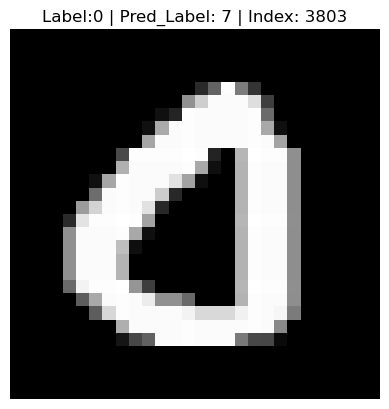

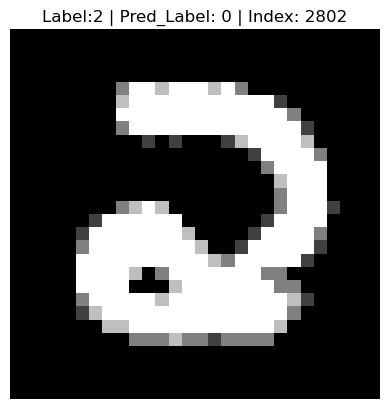

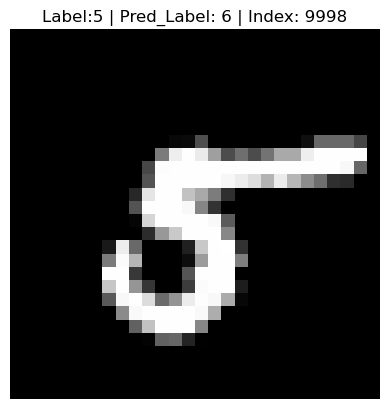

In [13]:
diff_indices = list(set(wrong_indices_pruned) - set(wrong_indices))
pred_dict_pruned = dict(wrong_samples_pruned)
random_indices = random.sample(diff_indices, 3)
for idx in random_indices[:3]:
    img, label = test_dataset[idx]
    print("Index:", idx)
    print("Label:", label)
    print("Shape:", img.shape)
    print("-" * 30)

for idx in random_indices[:3]:
    img, label = test_dataset[idx]
    pred_label = pred_dict_pruned[idx]

    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Label:{label} | Pred_Label: {pred_label} | Index: {idx}")
    plt.axis('off')
    plt.show()

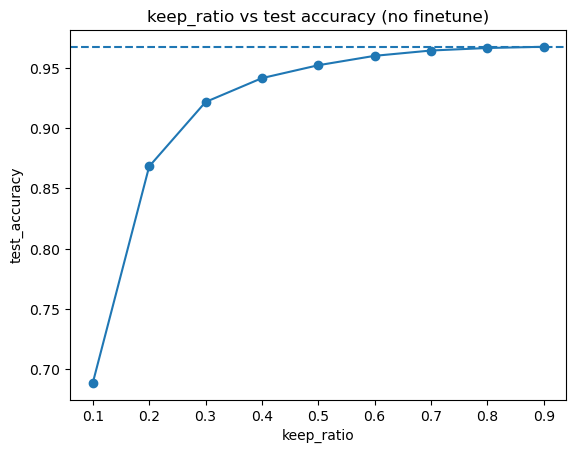

In [ ]:
methods = ["StrongRRQR"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        coeffs, biases, p, T = prune_model(model1, X, r, method=method)
        _, acc, _ = evaluate_pruned(coeffs, biases, test_loader, device)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")

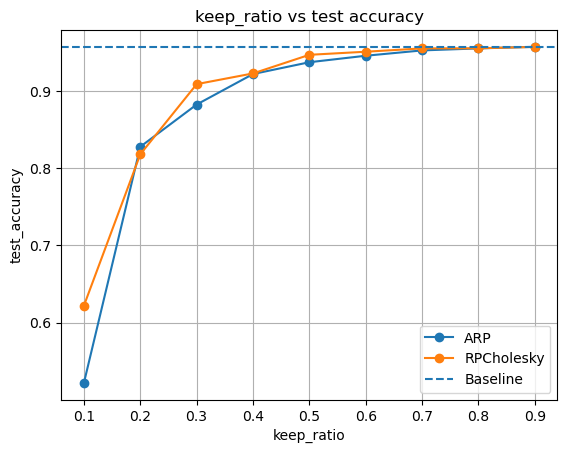

In [8]:
methods = ["ARP", "RPCholesky"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        coeffs, biases, p, T = prune_model(model1, X, r, method=method)
        _, acc = evaluate_pruned(coeffs, biases, test_loader, device)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")

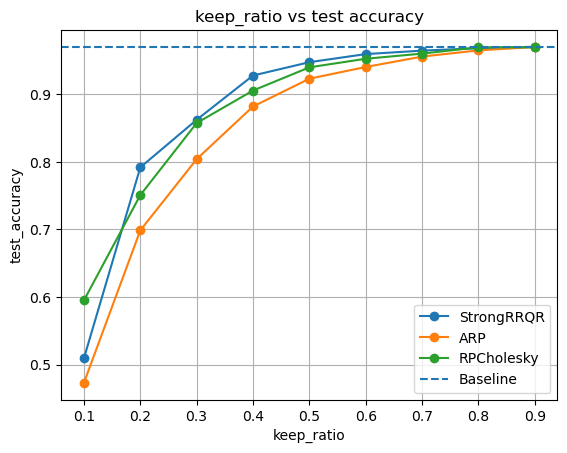

In [11]:
methods = ["StrongRRQR", "ARP", "RPCholesky"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        coeffs, biases, p, T = prune_model(model1, X, r, method=method)
        _, acc = evaluate_pruned(coeffs, biases, test_loader, device)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")